# Williamson Models

Fit Williamson curves to slurry viscosity measurements and build a row-level physics dataset for downstream modelling.

## 1. Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd

from scipy.optimize import least_squares
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/combined_slurry_data_expanded.csv')

print(f"Rows: {len(df)}  |  Unique formulations (Composite_Mix_ID): {df['Composite_Mix_ID'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Rows: 178  |  Unique formulations (Composite_Mix_ID): 68
Columns: ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s', 'Source_Batch', 'Composite_Mix_ID', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct']


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,Viscosity_at_shear_rate_1_1/s,Viscosity_at_shear_rate_10_1/s,Viscosity_at_shear_rate_100_1/s,Source_Batch,Composite_Mix_ID,NMC_pct,C65_pct,KS6L_pct,PVDF_pct
0,Hypermer,73.0,0.50,10.56640,3.78921,1.99755,Batch_1,F1_Hypermer_73.0_0.5,96.0,2.0,0.0,2.0
1,Hypermer,73.0,0.25,71.65190,14.08460,4.82515,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
2,Hypermer,73.0,0.25,9.64639,3.26827,1.61720,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
3,Hypermer,77.0,0.25,61.11070,18.77450,7.51220,Batch_1,F1_Hypermer_77.0_0.25,96.0,2.0,0.0,2.0
4,Hypermer,73.0,0.25,8.37111,4.83186,2.30422,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0


## 3. Define Williamson Model

In [3]:
def williamson_viscosity(shear_rate, eta_0, eta_inf, lambda_time, n_w):
    """
    Williamson model:
    eta = eta_inf + (eta_0 - eta_inf) / (1 + (lambda * gamma_dot)^n_w)

    Parameters
    ----------
    shear_rate   : array-like  -- applied shear rate (1/s)
    eta_0        : float       -- zero-shear viscosity
    eta_inf      : float       -- infinite-shear viscosity
    lambda_time  : float       -- time constant
    n_w          : float       -- Williamson exponent
    """
    return eta_inf + (eta_0 - eta_inf) / (1.0 + np.power(lambda_time * shear_rate, n_w))

## 4. Set Up Columns and Features

In [4]:
shear_rates = np.array([1.0, 10.0, 100.0], dtype=float)

target_cols = [
    'Viscosity_at_shear_rate_1_1/s',
    'Viscosity_at_shear_rate_10_1/s',
    'Viscosity_at_shear_rate_100_1/s',
]

eps = 1e-8
df['Solid_to_Liquid_Ratio'] = df['Solid_Content_pct'] / (100.0 - df['Solid_Content_pct'] + eps)
df['Binder_to_Active_Ratio'] = df['PVDF_pct'] / (df['NMC_pct'] + df['C65_pct'] + eps)

input_cols = [
    'Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct',
    'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch',
    'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio',
]

print('Target columns:', target_cols)
print('Input columns :', input_cols)
display(df[input_cols + ['Composite_Mix_ID']].head())

Target columns: ['Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s']
Input columns : ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch', 'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio']


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,NMC_pct,C65_pct,KS6L_pct,PVDF_pct,Source_Batch,Solid_to_Liquid_Ratio,Binder_to_Active_Ratio,Composite_Mix_ID
0,Hypermer,73.0,0.50,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.5
1,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.25
2,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.25
3,Hypermer,77.0,0.25,96.0,2.0,0.0,2.0,Batch_1,3.347826,0.020408,F1_Hypermer_77.0_0.25
4,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.25


## 5. Fit Williamson Parameters Per Row

In [5]:
USE_LOCKED_ETA_INF_ABLATION = True
LOCKED_ETA_INF = 0.01
USE_LOG_RESIDUALS_FOR_WILLIAMSON_FIT = True
FIT_LOG_LAMBDA = True
LOG_LAMBDA_BOUNDS = (-3.0, 3.0)
RESIDUAL_EPS = 1e-8

williamson_dataset = []
failed_fits = []

if USE_LOCKED_ETA_INF_ABLATION:
    def fit_row_williamson_model(x_values, y_values, initial_guess_free, bounds_free, reg_weight=1e-2):
        def residuals(theta_free):
            eta_0 = theta_free[0]
            if FIT_LOG_LAMBDA:
                lambda_time = np.exp(theta_free[1])
                n_w = theta_free[2]
            else:
                lambda_time = theta_free[1]
                n_w = theta_free[2]

            y_hat = williamson_viscosity(x_values, eta_0, LOCKED_ETA_INF, lambda_time, n_w)

            if USE_LOG_RESIDUALS_FOR_WILLIAMSON_FIT:
                data_resid = np.log(y_values + RESIDUAL_EPS) - np.log(y_hat + RESIDUAL_EPS)
            else:
                data_resid = y_values - y_hat

            reg_resid = np.sqrt(reg_weight) * (theta_free - initial_guess_free)
            return np.concatenate([data_resid, reg_resid])

        return least_squares(residuals, x0=initial_guess_free, bounds=bounds_free, max_nfev=20000)
else:
    def fit_row_williamson_model(x_values, y_values, initial_guess, bounds, reg_weight=1e-2):
        def residuals(theta):
            eta_0 = theta[0]
            eta_inf = theta[1]
            lambda_time = np.exp(theta[2]) if FIT_LOG_LAMBDA else theta[2]
            n_w = theta[3]

            y_hat = williamson_viscosity(x_values, eta_0, eta_inf, lambda_time, n_w)

            if USE_LOG_RESIDUALS_FOR_WILLIAMSON_FIT:
                data_resid = np.log(y_values + RESIDUAL_EPS) - np.log(y_hat + RESIDUAL_EPS)
            else:
                data_resid = y_values - y_hat

            reg_resid = np.sqrt(reg_weight) * (theta - initial_guess)
            return np.concatenate([data_resid, reg_resid])

        return least_squares(residuals, x0=initial_guess, bounds=bounds, max_nfev=20000)

mode_label = 'locked eta_inf=0.01' if USE_LOCKED_ETA_INF_ABLATION else 'full 4-parameter fit'
print(f'Williamson fit mode: {mode_label}')
print(f'Log residuals: {USE_LOG_RESIDUALS_FOR_WILLIAMSON_FIT} | Fit log(lambda): {FIT_LOG_LAMBDA}')
print(f'Fitting Williamson parameters for {len(df)} rows (entire dataset)...')

for row_idx, raw_row in df.iterrows():
    x_data = shear_rates
    y_data = raw_row[target_cols].values.astype(float)

    try:
        if USE_LOCKED_ETA_INF_ABLATION:
            if FIT_LOG_LAMBDA:
                initial_guess_free = np.array([np.max(y_data), np.log(1.0), 0.8], dtype=float)
                bounds_free = (
                    np.array([0.1, LOG_LAMBDA_BOUNDS[0], 0.05], dtype=float),
                    np.array([np.inf, LOG_LAMBDA_BOUNDS[1], 2.5], dtype=float),
                )
            else:
                initial_guess_free = np.array([np.max(y_data), 1.0, 0.8], dtype=float)
                bounds_free = (
                    np.array([0.1, 0.001, 0.05], dtype=float),
                    np.array([np.inf, 100.0, 2.5], dtype=float),
                )

            final_fit = fit_row_williamson_model(x_data, y_data, initial_guess_free, bounds_free)
            eta_0 = final_fit.x[0]
            lambda_time = np.exp(final_fit.x[1]) if FIT_LOG_LAMBDA else final_fit.x[1]
            n_w = final_fit.x[2]
            eta_inf = LOCKED_ETA_INF
        else:
            if FIT_LOG_LAMBDA:
                initial_guess = np.array([np.max(y_data), np.min(y_data), np.log(1.0), 0.8], dtype=float)
                bounds = (
                    np.array([0.1, 0.01, LOG_LAMBDA_BOUNDS[0], 0.05], dtype=float),
                    np.array([np.inf, np.max(y_data) + 50.0, LOG_LAMBDA_BOUNDS[1], 2.5], dtype=float),
                )
            else:
                initial_guess = np.array([np.max(y_data), np.min(y_data), 1.0, 0.8], dtype=float)
                bounds = (
                    np.array([0.1, 0.01, 0.001, 0.05], dtype=float),
                    np.array([np.inf, np.max(y_data) + 50.0, 100.0, 2.5], dtype=float),
                )

            final_fit = fit_row_williamson_model(x_data, y_data, initial_guess, bounds)
            eta_0 = final_fit.x[0]
            eta_inf = final_fit.x[1]
            lambda_time = np.exp(final_fit.x[2]) if FIT_LOG_LAMBDA else final_fit.x[2]
            n_w = final_fit.x[3]

        y_pred_all = williamson_viscosity(x_data, eta_0, eta_inf, lambda_time, n_w)
        w_rmse = np.sqrt(mean_squared_error(y_data, y_pred_all))
        w_r2 = r2_score(y_data, y_pred_all)
        w_mae = mean_absolute_error(y_data, y_pred_all)

        record = raw_row[input_cols].to_dict()
        record['row_index'] = row_idx
        record['Composite_Mix_ID'] = raw_row['Composite_Mix_ID']
        record['eta_0_w'] = eta_0
        record['eta_inf_w'] = eta_inf
        record['lambda_time_w'] = lambda_time
        record['n_w'] = n_w
        record['WILLIAMSON_N_RMSE'] = w_rmse
        record['WILLIAMSON_N_R2'] = w_r2
        record['WILLIAMSON_N_MAE'] = w_mae

        williamson_dataset.append(record)
    except Exception:
        failed_fits.append(row_idx)

print(f'Successful fits : {len(williamson_dataset)}')
print(f'Failed fits     : {len(failed_fits)}')

Williamson fit mode: locked eta_inf=0.01
Log residuals: True | Fit log(lambda): True
Fitting Williamson parameters for 178 rows (entire dataset)...
Successful fits : 178
Failed fits     : 0


## 6. Build Williamson Physics Dataset

In [6]:
physics_df = pd.DataFrame(williamson_dataset)
physics_df['w_confidence'] = 1.0 / (physics_df['WILLIAMSON_N_RMSE'] + 1e-6)

if USE_LOCKED_ETA_INF_ABLATION and 'eta_inf_w' in physics_df.columns:
    physics_df['eta_inf_w'] = LOCKED_ETA_INF

print(f'Physics dataset shape: {physics_df.shape}')
print(f"Unique formulations : {physics_df['Composite_Mix_ID'].nunique()}")
print('\nWilliamson parameter and fit summary:')
display(physics_df[['eta_0_w', 'eta_inf_w', 'lambda_time_w', 'n_w', 'WILLIAMSON_N_RMSE', 'WILLIAMSON_N_R2', 'WILLIAMSON_N_MAE']].describe().round(4))

print('\nDataset preview:')
display(physics_df.head())

Physics dataset shape: (178, 20)
Unique formulations : 68

Williamson parameter and fit summary:


,eta_0_w,eta_inf_w,lambda_time_w,n_w,WILLIAMSON_N_RMSE,WILLIAMSON_N_R2,WILLIAMSON_N_MAE
count,178.0000,178.00,178.0000,178.0000,178.0000,178.0000,178.0000
mean,53.7545,0.01,0.2797,0.5962,9.2839,0.8605,6.4649
std,65.6977,0.00,0.1468,0.1913,12.8226,0.0717,8.6967
min,2.1826,0.01,0.0498,0.1342,0.0362,0.6901,0.0288
25%,7.7400,0.01,0.1588,0.4757,0.4875,0.8038,0.3617
50%,24.4017,0.01,0.2489,0.6192,3.2953,0.8430,2.4603
75%,72.7947,0.01,0.3852,0.7503,13.4765,0.9304,9.3288
max,324.7625,0.01,0.8620,1.1090,64.8401,0.9898,43.3748



Dataset preview:


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,NMC_pct,C65_pct,KS6L_pct,PVDF_pct,Source_Batch,Solid_to_Liquid_Ratio,Binder_to_Active_Ratio,row_index,Composite_Mix_ID,eta_0_w,eta_inf_w,lambda_time_w,n_w,WILLIAMSON_N_RMSE,WILLIAMSON_N_R2,WILLIAMSON_N_MAE,w_confidence
0,Hypermer,73.0,0.50,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,0,F1_Hypermer_73.0_0.5,11.762339,0.01,0.222177,0.545625,1.467987,0.841759,1.130807,0.681205
1,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,1,F1_Hypermer_73.0_0.25,71.927257,0.01,0.376090,0.762853,13.528777,0.790574,9.513637,0.073917
2,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,2,F1_Hypermer_73.0_0.25,10.891423,0.01,0.257709,0.569923,1.339699,0.850260,1.024188,0.746436
3,Hypermer,77.0,0.25,96.0,2.0,0.0,2.0,Batch_1,3.347826,0.020408,3,F1_Hypermer_77.0_0.25,61.398614,0.01,0.214523,0.672888,9.443721,0.832501,6.863599,0.105890
4,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,4,F1_Hypermer_73.0_0.25,9.694116,0.01,0.097296,0.533265,0.491556,0.960974,0.325730,2.034353


## 7. Train-Test Split

In [7]:
unique_formulations = physics_df['Composite_Mix_ID'].dropna().unique()
form_train, form_test = train_test_split(
    unique_formulations,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

physics_train = physics_df[physics_df['Composite_Mix_ID'].isin(form_train)].copy()
physics_test = physics_df[physics_df['Composite_Mix_ID'].isin(form_test)].copy()

train_forms = set(physics_train['Composite_Mix_ID'].unique())
test_forms = set(physics_test['Composite_Mix_ID'].unique())
overlap_forms = train_forms & test_forms

print(f'Train set: {len(physics_train)} rows  |  {len(train_forms)} formulations')
print(f'Test set : {len(physics_test)} rows  |  {len(test_forms)} formulations')
print(f'Formulation overlap (must be 0): {len(overlap_forms)}')

Train set: 136 rows  |  54 formulations
Test set : 42 rows  |  14 formulations
Formulation overlap (must be 0): 0


## 8. ML Model Training

In [8]:
ml_feature_cols = input_cols
candidate_target_cols = ['eta_0_w', 'eta_inf_w', 'lambda_time_w', 'n_w']

if USE_LOCKED_ETA_INF_ABLATION:
    locked_target_cols = ['eta_inf_w']
else:
    locked_target_cols = [c for c in candidate_target_cols if physics_df[c].nunique(dropna=False) <= 1]

ml_target_cols = [c for c in candidate_target_cols if c not in locked_target_cols]

X_train = physics_train[ml_feature_cols].copy()
X_test = physics_test[ml_feature_cols].copy()
y_train_raw = physics_train[ml_target_cols].copy()
y_test_raw = physics_test[ml_target_cols].copy()

TARGET_LOG_EPS = 1e-8
y_train_model = np.log(y_train_raw.clip(lower=TARGET_LOG_EPS))

sample_weight_train = physics_train['w_confidence'].copy()
sample_weight_train = sample_weight_train / sample_weight_train.mean()
sample_weight_train = sample_weight_train.clip(lower=0.25, upper=4.0)
sample_noise_train = 1e-4 / sample_weight_train.values

X_train_encoded = pd.get_dummies(X_train, columns=['Dispersent_Type', 'Source_Batch'], drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=['Dispersent_Type', 'Source_Batch'], drop_first=False)

missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train_encoded.columns]

X_train_encoded = X_train_encoded.fillna(X_train_encoded.mean())
X_test_encoded = X_test_encoded.fillna(X_train_encoded.mean())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f'ML training set: {X_train.shape}')
print(f'ML test set:     {X_test.shape}')
print(f'Targets: {ml_target_cols}')
if locked_target_cols:
    print(f'Locked targets excluded: {locked_target_cols}')

ML training set: (136, 10)
ML test set:     (42, 10)
Targets: ['eta_0_w', 'lambda_time_w', 'n_w']
Locked targets excluded: ['eta_inf_w']


### 8.1 Gaussian Process Regression

In [9]:
gpr_models = {}
gpr_train_r2 = {}
gpr_test_r2 = {}

for target_param in ml_target_cols:
    kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=sample_noise_train, random_state=42)

    gpr.fit(X_train_scaled, y_train_model[target_param])
    gpr_models[target_param] = gpr

    y_pred_train = np.exp(gpr.predict(X_train_scaled))
    y_pred_test = np.exp(gpr.predict(X_test_scaled))

    gpr_train_r2[target_param] = r2_score(y_train_raw[target_param], y_pred_train)
    gpr_test_r2[target_param] = r2_score(y_test_raw[target_param], y_pred_test)

print('GPR Model Performance:')
print('\nTrain R2 scores:')
for param, r2 in gpr_train_r2.items():
    print(f'  {param:15s}: {r2:.4f}')

print('\nTest R2 scores:')
for param, r2 in gpr_test_r2.items():
    print(f'  {param:15s}: {r2:.4f}')

GPR Model Performance:

Train R2 scores:
  eta_0_w        : 0.7463
  lambda_time_w  : 0.1900
  n_w            : 0.7405

Test R2 scores:
  eta_0_w        : 0.6956
  lambda_time_w  : 0.0859
  n_w            : 0.4752


### 8.2 Random Forest and Extra Trees

In [10]:
rf_models = {}
et_models = {}
rf_train_r2, rf_test_r2 = {}, {}
et_train_r2, et_test_r2 = {}, {}

for target_param in ml_target_cols:
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train_encoded, y_train_model[target_param], sample_weight=sample_weight_train.values)
    rf_models[target_param] = rf
    rf_train_r2[target_param] = r2_score(y_train_raw[target_param], np.exp(rf.predict(X_train_encoded)))
    rf_test_r2[target_param] = r2_score(y_test_raw[target_param], np.exp(rf.predict(X_test_encoded)))

    et = ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    et.fit(X_train_encoded, y_train_model[target_param], sample_weight=sample_weight_train.values)
    et_models[target_param] = et
    et_train_r2[target_param] = r2_score(y_train_raw[target_param], np.exp(et.predict(X_train_encoded)))
    et_test_r2[target_param] = r2_score(y_test_raw[target_param], np.exp(et.predict(X_test_encoded)))

comparison = pd.DataFrame({
    'Parameter': ml_target_cols,
    'GPR_Train_R2': [gpr_train_r2[p] for p in ml_target_cols],
    'GPR_Test_R2': [gpr_test_r2[p] for p in ml_target_cols],
    'RF_Train_R2': [rf_train_r2[p] for p in ml_target_cols],
    'RF_Test_R2': [rf_test_r2[p] for p in ml_target_cols],
    'ET_Train_R2': [et_train_r2[p] for p in ml_target_cols],
    'ET_Test_R2': [et_test_r2[p] for p in ml_target_cols],
})

display(comparison.round(4))

,Parameter,GPR_Train_R2,GPR_Test_R2,RF_Train_R2,RF_Test_R2,ET_Train_R2,ET_Test_R2
0,eta_0_w,0.7463,0.6956,0.7926,0.6786,0.8021,0.6307
1,lambda_time_w,0.1900,0.0859,0.5292,0.0550,0.5325,0.0130
2,n_w,0.7405,0.4752,0.8095,0.2319,0.7837,0.0600


### 8.3 Real vs Predicted Viscosity (Williamson, Test Set)

Compare measured viscosity against viscosity reconstructed from predicted Williamson parameters on the held-out test set.

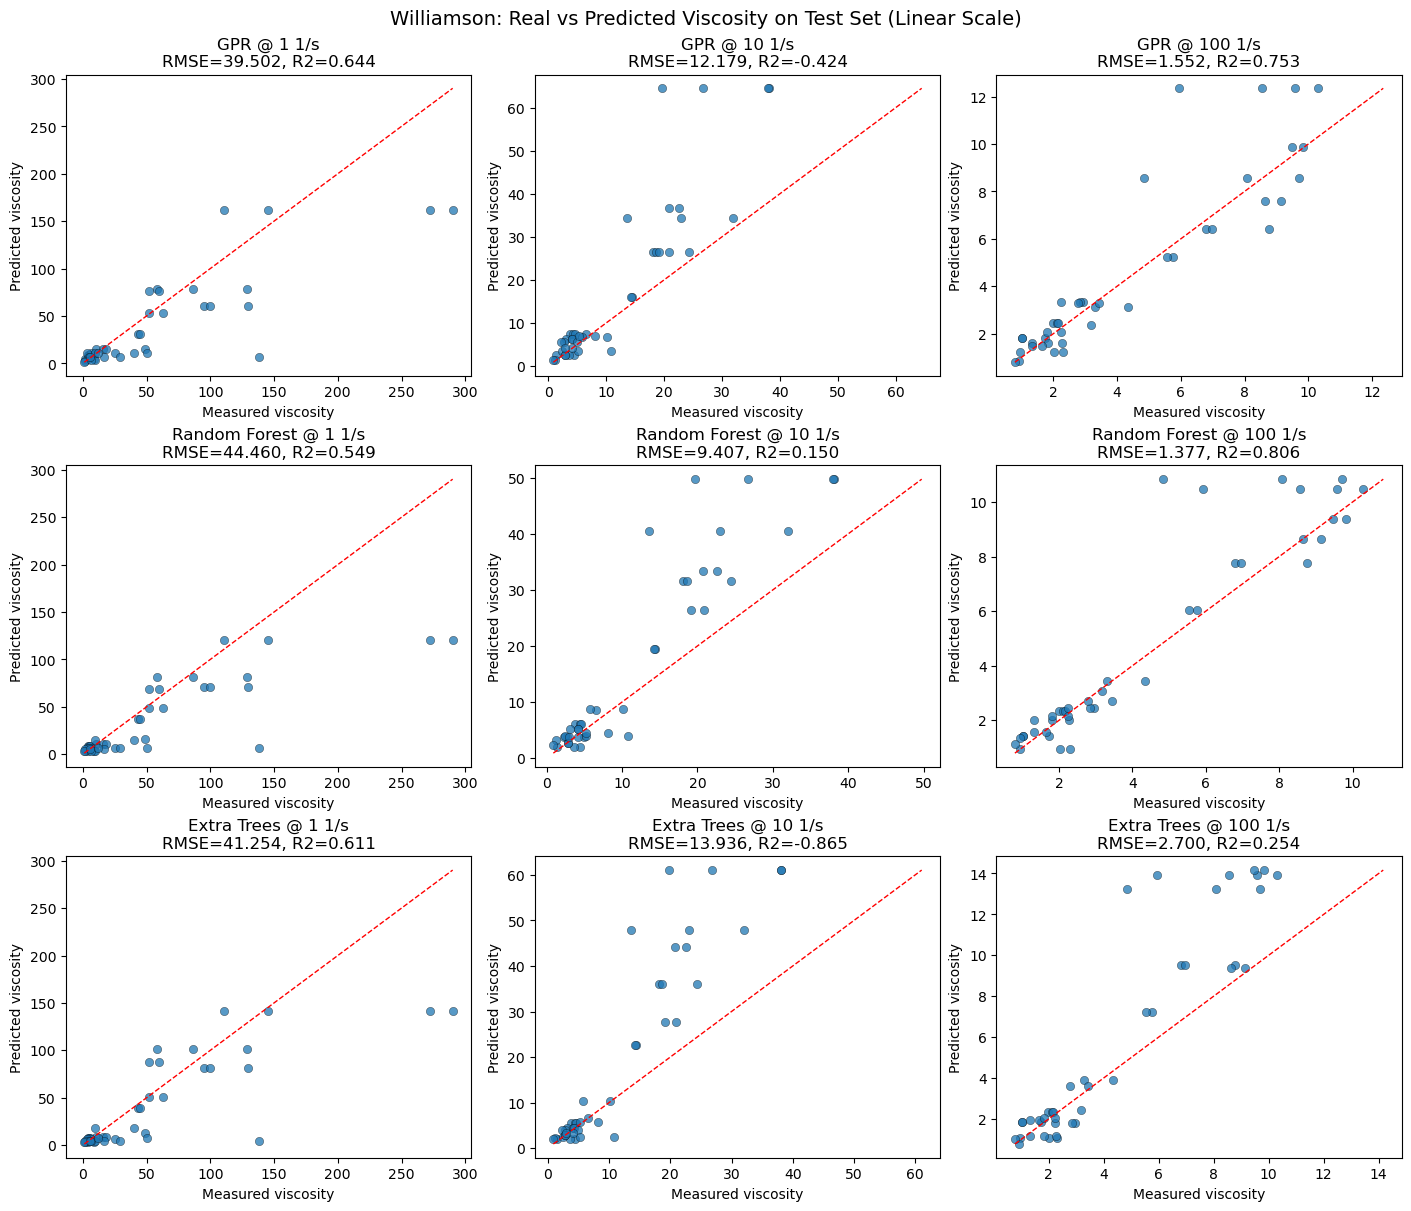

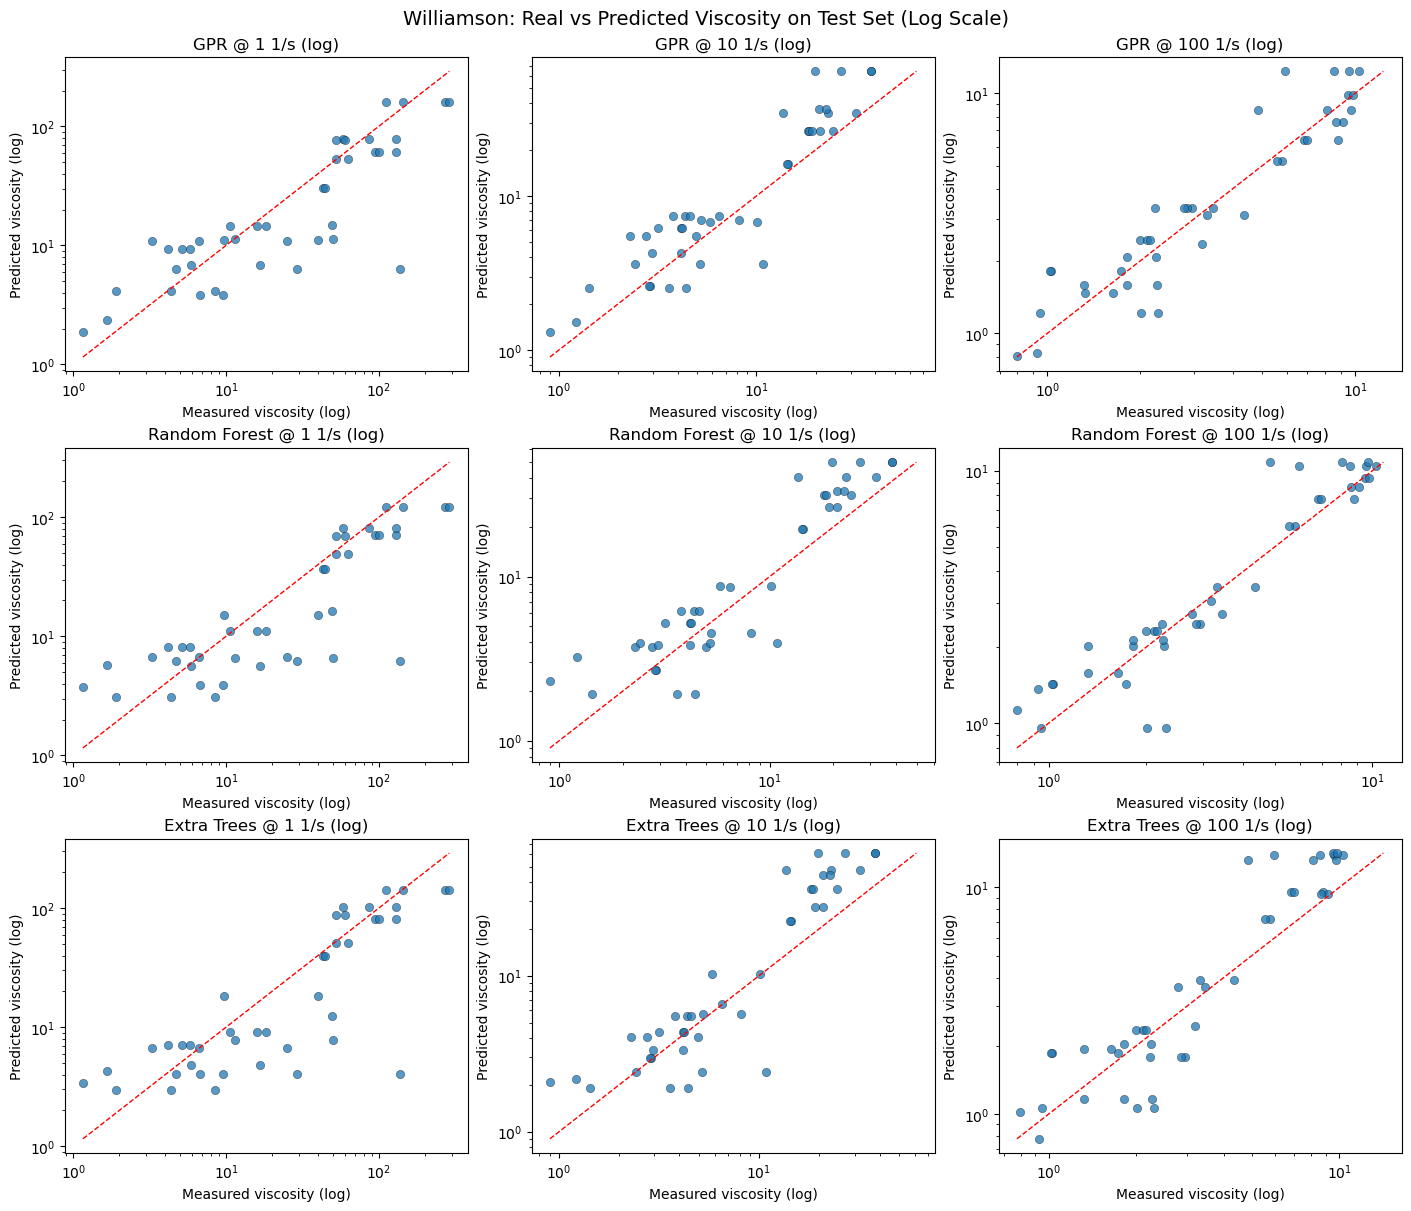

Williamson Viscosity Reconstruction Summary (Test Set):


,Model,ShearRate_1_per_s,RMSE,R2
6,Extra Trees,1,41.2539,0.6114
7,Extra Trees,10,13.9356,-0.8646
8,Extra Trees,100,2.7004,0.2537
0,GPR,1,39.5019,0.6438
1,GPR,10,12.1792,-0.4242
2,GPR,100,1.5522,0.7534
3,Random Forest,1,44.4595,0.5487
4,Random Forest,10,9.4069,0.1504
5,Random Forest,100,1.3775,0.8058


In [11]:
import matplotlib.pyplot as plt

# Build test dataframe with measured viscosities via row_index mapping
test_rows = df.loc[physics_test['row_index'], target_cols].copy().reset_index(drop=True)

# Predict Williamson parameters on test set (models output log-parameters)
pred_gpr_w = pd.DataFrame({p: np.exp(gpr_models[p].predict(X_test_scaled)) for p in ml_target_cols})
pred_rf_w = pd.DataFrame({p: np.exp(rf_models[p].predict(X_test_encoded)) for p in ml_target_cols})
pred_et_w = pd.DataFrame({p: np.exp(et_models[p].predict(X_test_encoded)) for p in ml_target_cols})

# Fill locked or excluded parameters if needed for viscosity reconstruction
for locked_col in ['eta_inf_w']:
    if locked_col not in pred_gpr_w.columns:
        pred_gpr_w[locked_col] = physics_test[locked_col].values
        pred_rf_w[locked_col] = physics_test[locked_col].values
        pred_et_w[locked_col] = physics_test[locked_col].values

for maybe_col in ['eta_0_w', 'lambda_time_w', 'n_w']:
    if maybe_col not in pred_gpr_w.columns:
        pred_gpr_w[maybe_col] = physics_test[maybe_col].values
        pred_rf_w[maybe_col] = physics_test[maybe_col].values
        pred_et_w[maybe_col] = physics_test[maybe_col].values

# Ensure full Williamson parameter order
param_order = ['eta_0_w', 'eta_inf_w', 'lambda_time_w', 'n_w']
pred_gpr_w = pred_gpr_w[param_order]
pred_rf_w = pred_rf_w[param_order]
pred_et_w = pred_et_w[param_order]

model_preds_w = {
    'GPR': pred_gpr_w,
    'Random Forest': pred_rf_w,
    'Extra Trees': pred_et_w,
}

rate_to_col = {
    1.0: 'Viscosity_at_shear_rate_1_1/s',
    10.0: 'Viscosity_at_shear_rate_10_1/s',
    100.0: 'Viscosity_at_shear_rate_100_1/s',
}

metrics_records_w = []

# Linear-scale scatter plots
fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)

for row_i, (model_name, pred_params) in enumerate(model_preds_w.items()):
    for col_i, shear_rate in enumerate([1.0, 10.0, 100.0]):
        ax = axes[row_i, col_i]

        y_true = test_rows[rate_to_col[shear_rate]].values
        y_pred = williamson_viscosity(
            shear_rate,
            pred_params['eta_0_w'].values,
            pred_params['eta_inf_w'].values,
            pred_params['lambda_time_w'].values,
            pred_params['n_w'].values,
        )

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        metrics_records_w.append(
            {
                'Model': model_name,
                'ShearRate_1_per_s': int(shear_rate),
                'RMSE': rmse,
                'R2': r2,
            }
        )

        ax.scatter(y_true, y_pred, alpha=0.75, edgecolor='k', linewidth=0.3)
        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1)

        ax.set_title(f"{model_name} @ {int(shear_rate)} 1/s\nRMSE={rmse:.3f}, R2={r2:.3f}")
        ax.set_xlabel('Measured viscosity')
        ax.set_ylabel('Predicted viscosity')

plt.suptitle('Williamson: Real vs Predicted Viscosity on Test Set (Linear Scale)', fontsize=14)
plt.show()

# Log-scale scatter plots (only positive values)
fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)

for row_i, (model_name, pred_params) in enumerate(model_preds_w.items()):
    for col_i, shear_rate in enumerate([1.0, 10.0, 100.0]):
        ax = axes[row_i, col_i]

        y_true = test_rows[rate_to_col[shear_rate]].values
        y_pred = williamson_viscosity(
            shear_rate,
            pred_params['eta_0_w'].values,
            pred_params['eta_inf_w'].values,
            pred_params['lambda_time_w'].values,
            pred_params['n_w'].values,
        )

        pos_mask = (y_true > 0) & (y_pred > 0)
        y_true_pos = y_true[pos_mask]
        y_pred_pos = y_pred[pos_mask]

        ax.scatter(y_true_pos, y_pred_pos, alpha=0.75, edgecolor='k', linewidth=0.3)

        if len(y_true_pos) > 0:
            min_v = min(y_true_pos.min(), y_pred_pos.min())
            max_v = max(y_true_pos.max(), y_pred_pos.max())
            ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f"{model_name} @ {int(shear_rate)} 1/s (log)")
        ax.set_xlabel('Measured viscosity (log)')
        ax.set_ylabel('Predicted viscosity (log)')

plt.suptitle('Williamson: Real vs Predicted Viscosity on Test Set (Log Scale)', fontsize=14)
plt.show()

# Compact summary table
viscosity_summary_w = pd.DataFrame(metrics_records_w).sort_values(['Model', 'ShearRate_1_per_s'])
print('Williamson Viscosity Reconstruction Summary (Test Set):')
display(viscosity_summary_w.round(4))

### 8.4 Fitted Williamson Viscosity Curves

Plot smooth fitted Williamson curves for a few representative formulations alongside the measured viscosity points.

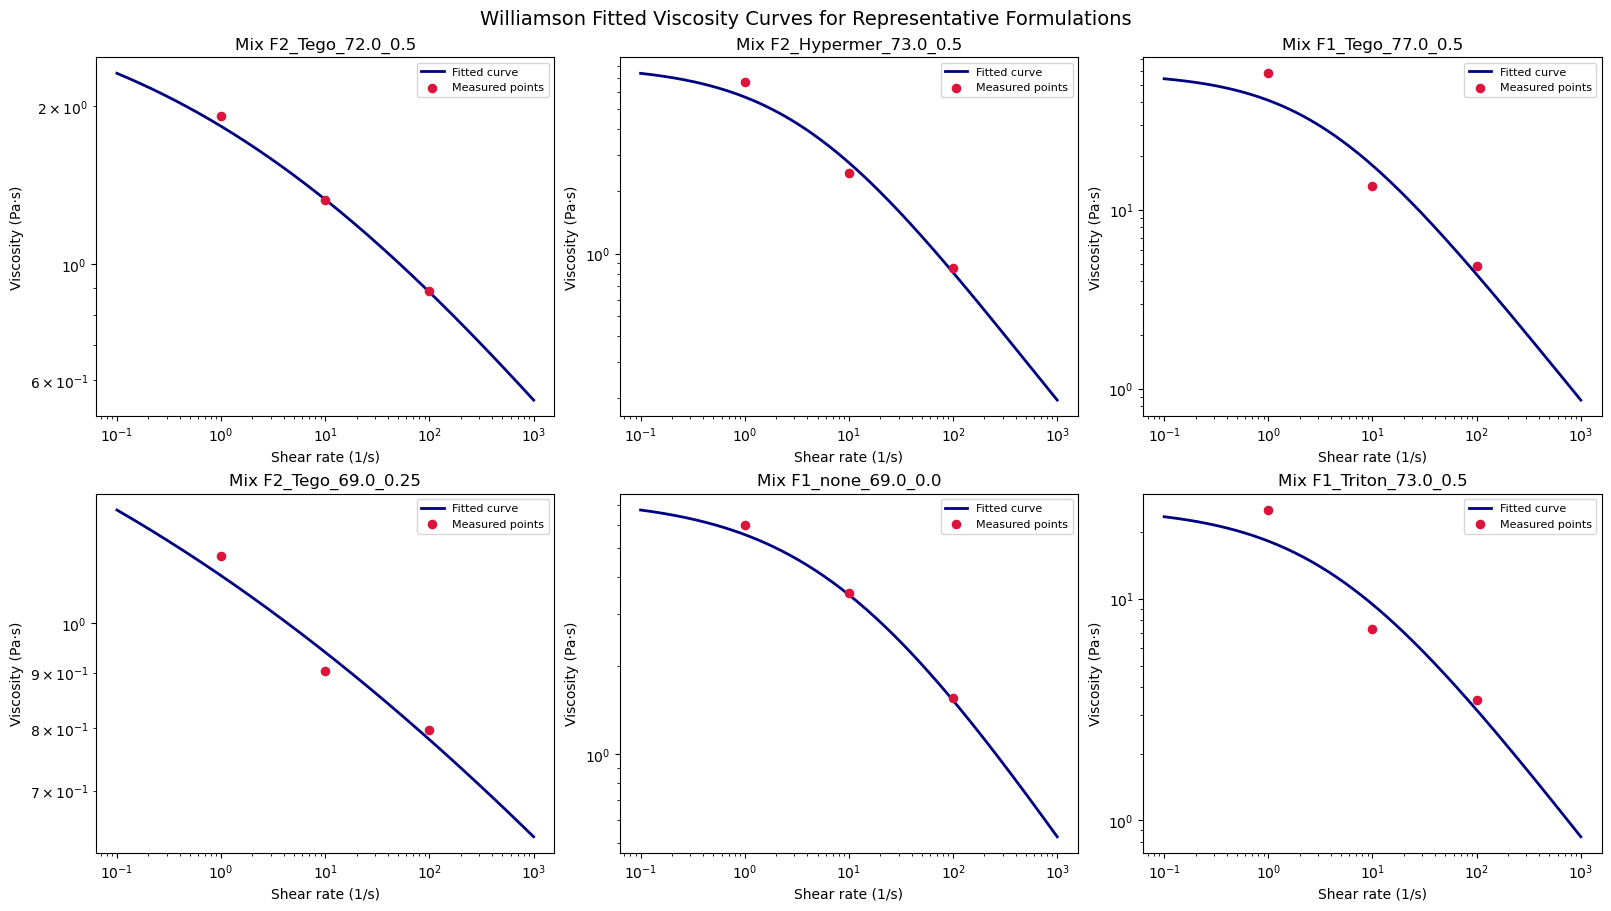

Representative fitted-curve quality:


,Composite_Mix_ID,WILLIAMSON_N_RMSE,WILLIAMSON_N_R2,WILLIAMSON_N_MAE
0,F2_Tego_72.0_0.5,0.0467,0.9876,0.0288
1,F2_Hypermer_73.0_0.5,0.6288,0.9360,0.4582
2,F1_Tego_77.0_0.5,10.1257,0.8112,7.2081
3,F2_Tego_69.0_0.25,0.0362,0.9417,0.0338
4,F1_none_69.0_0.0,0.2459,0.9816,0.1628
5,F1_Triton_73.0_0.5,4.2089,0.8024,3.1361


In [12]:
import matplotlib.pyplot as plt

# Always include the requested formulation if it exists, then add a few more representative rows
requested_mix_id = 'F2_Tego_72.0_0.5'
requested_rows = physics_df[physics_df['Composite_Mix_ID'].astype(str).str.lower() == requested_mix_id.lower()]
sample_rows = physics_df.sample(n=min(5, len(physics_df)), random_state=42).copy()

if not requested_rows.empty:
    plot_rows = pd.concat([requested_rows.head(1), sample_rows], ignore_index=True)
else:
    plot_rows = sample_rows.copy()

plot_rows = plot_rows.drop_duplicates(subset=['Composite_Mix_ID']).head(6).copy()
shear_grid = np.logspace(-1, 3, 250)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, plot_rows.iterrows()):
    if USE_LOCKED_ETA_INF_ABLATION:
        eta_0 = row['eta_0_w']
        eta_inf = row['eta_inf_w']
        lambda_time = row['lambda_time_w']
        n_w = row['n_w']
    else:
        eta_0 = row['eta_0_w']
        eta_inf = row['eta_inf_w']
        lambda_time = row['lambda_time_w']
        n_w = row['n_w']

    curve = williamson_viscosity(shear_grid, eta_0, eta_inf, lambda_time, n_w)
    measured = df.loc[row['row_index'], target_cols].values.astype(float)

    ax.plot(shear_grid, curve, color='navy', linewidth=2, label='Fitted curve')
    ax.scatter(shear_rates, measured, color='crimson', s=35, zorder=3, label='Measured points')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Shear rate (1/s)')
    ax.set_ylabel('Viscosity (Pa·s)')
    ax.set_title(f"Mix {row['Composite_Mix_ID']}")
    ax.legend(fontsize=8)

# Hide unused axes if fewer than 6 rows are available
for ax in axes[len(plot_rows):]:
    ax.axis('off')

plt.suptitle('Williamson Fitted Viscosity Curves for Representative Formulations', fontsize=14)
plt.show()

# Summarize the fitted-curve quality for the selected rows
curve_quality = plot_rows[['Composite_Mix_ID', 'WILLIAMSON_N_RMSE', 'WILLIAMSON_N_R2', 'WILLIAMSON_N_MAE']].copy()
print('Representative fitted-curve quality:')
display(curve_quality.round(4))